# Tutorial 3. Use SEDR to do batch integration.

Here we use 3 sections from DLPFC data to show the ability of SEDR to integrate batches for the same tissue with the same techniques. 

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm



In [2]:
import SEDR

In [3]:
SEDR.fix_seed(1)

In [5]:
def mapping2int(string_array):
    mapping = {}
    result = []
    for string in string_array:
        if string not in mapping:
            mapping[string] = len(mapping)
        result.append(mapping[string])
    return result, mapping

import anndata as ad

#load data
count = pd.read_csv(
        "../../../data/Mouse_Brain/GSE147747/GSE147747_expr_raw_counts_table.tsv",
        sep="\t", index_col=0)
meta = pd.read_csv("../../../data/Mouse_Brain/GSE147747/GSE147747_meta_table.tsv",
                       sep="\t",
                       index_col=0)

In [6]:
#creat adata
adata_st_all = ad.AnnData(X=count.values)
adata_st_all.obs.index = count.index
adata_st_all.obs = meta.loc[adata_st_all.obs.index]
adata_st_all.var.index = count.columns

slice_use = ['01A', '02A', '03A', '04B', '05A', '06B', '07A', '08B', '09A', '10B',
                 '11A', '12A', '13B', '14A', '15A', '16A', '17A', '18A', '19A', '20B',
                 '21A', '22A', '23A', '24A', '25A', '26A', '27A', '28A', '29A', '30A',
                 '31A', '32A', '33A', '34A', '35A', ]

result, mapping = mapping2int(slice_use)

adata_st_all = adata_st_all[[s in slice_use for s in adata_st_all.obs.section_index.values]]
sc.pp.filter_cells(adata_st_all, min_genes=1)

adata_st_all.obsm['spatial'] = np.concatenate(
        (adata_st_all.obs['HE_X'].values.reshape(-1, 1), adata_st_all.obs['HE_Y'].values.reshape(-1, 1)), axis=1)

for i, slice_id in enumerate(sorted(set(adata_st_all.obs.section_index.values))):
        adata_tmp = adata_st_all[adata_st_all.obs.section_index.values == slice_id]
        array_col = np.array([np.float32(loc.split("_")[1].split("x")[0]) for loc in adata_tmp.obs.index])
        if slice_id == '01A':
            array_col = array_col - 0.3
        array_row = np.array([np.float32(loc.split("_")[1].split("x")[1]) for loc in adata_tmp.obs.index])
        
        adata_tmp.obs['array_col'] = np.round(array_col)
        adata_tmp.obs['array_row'] = np.round(array_row)

        adata_tmp.obs['batch_name'] = slice_id
        adata_tmp.obs['slice_id'] = mapping[slice_id]
        
        adata_tmp.var_names_make_unique()
        
        # Remove mt-genes
        adata_tmp = adata_tmp[:, (np.array(~adata_tmp.var.index.str.startswith("mt-"))
                                  & np.array(~adata_tmp.var.index.str.startswith("MT-")))]
        adata_tmp.obs.index = adata_tmp.obs.index + "-slice%d" % i

        adata_tmp = adata_tmp[~pd.isnull(adata_tmp.obs['ABA_parent'])]

        graph_dict_tmp = SEDR.graph_construction(adata_tmp, 12)
        
        if i == 0:
            adata = adata_tmp
            graph_dict = graph_dict_tmp
            name = slice_id
            adata.obs['proj_name'] = slice_id
        else:
            var_names = adata.var_names.intersection(adata_tmp.var_names)
            adata = adata[:, var_names]
            adata_tmp = adata_tmp[:, var_names]
            adata_tmp.obs['proj_name'] = slice_id

            adata = adata.concatenate(adata_tmp)
            graph_dict = SEDR.combine_graph_dict(graph_dict, graph_dict_tmp)
            name = name + '_' + slice_id

## Preprocessing

In [8]:
adata.layers['count'] = adata.X
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

## Training SEDR

In [9]:
sedr_net = SEDR.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device='cuda:0')
using_dec = False
if using_dec:
    sedr_net.train_with_dec()
else:
    sedr_net.train_without_dec()
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat

100%|██████████| 200/200 [00:16<00:00, 12.20it/s]


## use harmony to calculate revised PCs

In [10]:
import harmonypy as hm

meta_data = adata.obs[['batch_name']]

data_mat = adata.obsm['SEDR']
vars_use = ['batch_name']
ho = hm.run_harmony(data_mat, meta_data, vars_use)

res = pd.DataFrame(ho.Z_corr).T
res_df = pd.DataFrame(data=res.values, columns=['X{}'.format(i+1) for i in range(res.shape[1])], index=adata.obs.index)
adata.obsm[f'SEDR.Harmony'] = res_df.to_numpy()

2024-12-31 11:55:20,604 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-12-31 11:55:22,965 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-12-31 11:55:23,054 - harmonypy - INFO - Iteration 1 of 10
2024-12-31 11:55:27,718 - harmonypy - INFO - Iteration 2 of 10
2024-12-31 11:55:32,392 - harmonypy - INFO - Iteration 3 of 10
2024-12-31 11:55:36,978 - harmonypy - INFO - Iteration 4 of 10
2024-12-31 11:55:41,903 - harmonypy - INFO - Iteration 5 of 10
2024-12-31 11:55:46,789 - harmonypy - INFO - Iteration 6 of 10
2024-12-31 11:55:51,244 - harmonypy - INFO - Iteration 7 of 10
2024-12-31 11:55:56,271 - harmonypy - INFO - Iteration 8 of 10
2024-12-31 11:56:00,905 - harmonypy - INFO - Iteration 9 of 10
2024-12-31 11:56:04,213 - harmonypy - INFO - Iteration 10 of 10
2024-12-31 11:56:07,731 - harmonypy - INFO - Stopped before convergence


In [11]:
SEDR.mclust_R(adata, use_rep='SEDR.Harmony', key_added='mclust', n_clusters=15)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 17086 × 2000
    obs: 'section_index', 'stereo_ML', 'stereo_DV', 'stereo_AP', 'HE_X', 'HE_Y', 'ABA_acronym', 'ABA_name', 'ABA_parent', 'nuclei_segmented', 'spot_radius', 'passed_QC', 'cluster_id', 'cluster_name', 'n_genes', 'array_col', 'array_row', 'batch_name', 'slice_id', 'proj_name', 'batch', 'mclust'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'X_pca', 'SEDR', 'SEDR.Harmony'
    layers: 'count'

In [13]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [14]:
sub_adata = adata[~pd.isnull(adata.obs['ABA_parent'])]
ARI = ari_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
ARI_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")
    ARI_list.append(ARI)
print('Mean:',np.mean(ARI_list))
print('Median:',np.median(ARI_list))

total ARI:0.34907137638979074
01A ARI:0.44909716092349283
02A ARI:0.33025604098665434
03A ARI:0.2502619975457139
04B ARI:0.2562375484004972
05A ARI:0.2824403113782179
06B ARI:0.3175952222782874
07A ARI:0.33215705845420984
08B ARI:0.3381420613525631
09A ARI:0.381134625258538
10B ARI:0.3869589921934892
11A ARI:0.3624868823588681
12A ARI:0.38443153997688456
13B ARI:0.38121252437773845
14A ARI:0.41028014104803723
15A ARI:0.3740824299616666
16A ARI:0.3759591762866119
17A ARI:0.4042038812360047
18A ARI:0.4004130121532603
19A ARI:0.42010651434595697
20B ARI:0.428928312626221
21A ARI:0.4499198871136754
22A ARI:0.4198464741203072
23A ARI:0.40015611303181364
24A ARI:0.40391763673789494
25A ARI:0.441291667141433
26A ARI:0.4360010142948741
27A ARI:0.46249353668864807
28A ARI:0.4046155805229301
29A ARI:0.4198254706518817
30A ARI:0.38243693636994724
31A ARI:0.36166698157412597
32A ARI:0.31451949120753103
33A ARI:0.3112049139152383
34A ARI:0.37069934493870693
35A ARI:0.41338535992782044
Mean: 0.37881

In [15]:
sub_adata = adata[~pd.isnull(adata.obs['ABA_parent'])]
NMI = nmi_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total AMI:{AMI}")
NMI_list = []
AMI_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    AMI = ami_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    ACC = 1/2 * (NMI + AMI)
    print(f"{name} ACC:{ACC}")
    NMI_list.append(NMI)
    AMI_list.append(AMI)
print('NMI Mean:',np.mean(NMI_list))
print('NMI Median:',np.median(NMI_list))
print('AMI Mean:',np.mean(AMI_list))
print('AMI Median:',np.median(AMI_list))

total NMI:0.5493745606756993
total AMI:0.548284080850338
01A ACC:0.45221782619945483
02A ACC:0.4349591946151232
03A ACC:0.4067123517714494
04B ACC:0.45563036785636357
05A ACC:0.4746680839662105
06B ACC:0.5301092124587721
07A ACC:0.5595030793562608
08B ACC:0.5412579129276995
09A ACC:0.5950446910302818
10B ACC:0.5887000927825492
11A ACC:0.5654029723701702
12A ACC:0.6021313920746498
13B ACC:0.6088666662155517
14A ACC:0.6068211555834032
15A ACC:0.5910136475987409
16A ACC:0.596163860562605
17A ACC:0.6311502339861688
18A ACC:0.6208389930531564
19A ACC:0.6203985281936155
20B ACC:0.6498952617707452
21A ACC:0.6538142544486356
22A ACC:0.6354067523442737
23A ACC:0.6298307926347222
24A ACC:0.6025834496358646
25A ACC:0.5635250463253978
26A ACC:0.5897906844828897
27A ACC:0.6028229577950216
28A ACC:0.5715364605843409
29A ACC:0.5727903295237826
30A ACC:0.5438854054178318
31A ACC:0.5388566831135266
32A ACC:0.4576307555084129
33A ACC:0.4792927914768425
34A ACC:0.523369710714687
35A ACC:0.559175617046141

In [16]:
sub_adata = adata[~pd.isnull(adata.obs['ABA_parent'])]
HOM = hom_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata.obs['ABA_parent'], sub_adata.obs['mclust'])
print(f"total COM:{COM}")
V_list = []
for name in slice_use:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    COM = com_score(sub_adata_tmp.obs['ABA_parent'], sub_adata_tmp.obs['mclust'])
    V =  2 * ((HOM * COM) / (HOM + COM))
    print(f"{name} V:{V}")
    V_list.append(V)
print('V Mean:',np.mean(V_list))
print('V Median:',np.median(V_list))

total HOM:0.5939617568705341
total COM:0.5110140384264505
01A V:0.46072337574395444
02A V:0.4403757946019377
03A V:0.41968971111379005
04B V:0.46859557734701013
05A V:0.4869298998850576
06B V:0.5426367259217099
07A V:0.5694913531221334
08B V:0.5534903188352784
09A V:0.6044022423258636
10B V:0.5982969157497269
11A V:0.5777844008113865
12A V:0.6135013767786512
13B V:0.620293460739496
14A V:0.618303550402166
15A V:0.6032764242812528
16A V:0.6083145075966994
17A V:0.6415213896953722
18A V:0.6324282617995084
19A V:0.6316957119271747
20B V:0.6612196269316266
21A V:0.662714406261651
22A V:0.6447788346546128
23A V:0.6399060412081023
24A V:0.6134605214472032
25A V:0.5757114660722678
26A V:0.600382276280822
27A V:0.6114924948344524
28A V:0.5805042884852503
29A V:0.5809265840203317
30A V:0.552240525332915
31A V:0.5462391143355302
32A V:0.4660957735543112
33A V:0.48502968674310115
34A V:0.5296015671422651
35A V:0.566827005135867
V Mean: 0.5716823203176707
V Median: 0.5809265840203317


7.371779141779992
1.211825762035564


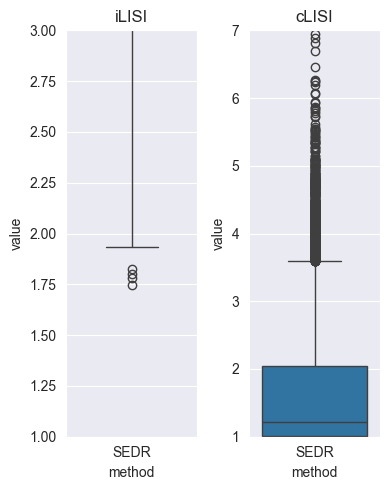

In [18]:
import seaborn as sns
import harmonypy as hm
import matplotlib.pyplot as plt

iLISI = hm.compute_lisi(adata.obsm['SEDR.Harmony'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
cLISI = hm.compute_lisi(adata.obsm['SEDR.Harmony'], adata.obs[['ABA_parent']], label_colnames=['ABA_parent'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))

## Visualizing

### UMAP